In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv('database/train_mod.csv')
df.head()

,ID,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
0,45654403,1399,LEXUS,RX 450,2010,SUV,Sim,Hibrido,3.5,186005 km,...,12,13328.0,1,2021-03-14,Sim,FM,8,8497,Usado,Econômico
1,44731507,1018,CHEVROLET,Equinox,2011,SUV,Nao,GASOLINA,3,NaN,...,8,16621.0,5,2021-08-08,Sim,AM,4,6796,Usado,Econômico
2,45774419,-,HONDA,FIT,2006,Hatchback,Nao,GASOLINA,1.3,200000 km,...,2,8467.0,1,2020-04-14,Sim,FM,5,3382,Usado,Econômico
3,45769185,862,FORD,Escape,2011,SUV,Sim,Hibrido,2.5,168966 km,...,0,3607.0,1,2020-01-13,Não,AM/FM,7,1458,Usado,Econômico
4,45809263,446,HONDA,FIT,2014,Hatchback,Sim,Gasolina,1.3,91901 km,...,4,11726.0,2,2021-10-11,Não,AM,5,5374,Usado,Econômico


In [16]:
df.shape

(8685, 26)

In [17]:
df["Fabricante"].value_counts()

Fabricante
TOYOTA           1794
HYUNDAI          1496
MERCEDES-BENZ     939
FORD              507
BMW               483
HONDA             469
CHEVROLET         468
LEXUS             460
NISSAN            275
VOLKSWAGEN        250
SSANGYONG         215
OPEL              185
KIA               176
MITSUBISHI        136
SUBARU            127
AUDI              114
MAZDA              81
JEEP               61
DAEWOO             45
SUZUKI             44
DODGE              39
FIAT               39
PORSCHE            29
LAND ROVER         28
VAZ                27
MINI               22
RENAULT            21
JAGUAR             19
CHRYSLER           12
INFINITI           11
ACURA              10
SKODA               9
LINCOLN             9
CADILLAC            9
DAIHATSU            8
GMC                 8
GAZ                 7
VOLVO               7
BUICK               5
PEUGEOT             4
CITROEN             4
ISUZU               3
SCION               3
UAZ                 3
MOSKVICH            3

In [18]:
df["Ano"].value_counts()

Ano
2012    994
2014    946
2013    943
2011    736
2010    713
2016    632
2015    608
2017    430
2008    322
2009    259
2018    234
2007    217
2004    172
2003    165
2002    158
2005    156
2006    147
2019    147
2000    119
1998    109
2001    105
1999     90
1997     61
1996     55
1995     54
1994     21
1992     16
2020     15
1993     13
1988      7
1991      7
1989      6
1990      5
1984      5
1983      3
1974      2
1953      2
1985      2
1986      2
1964      1
1977      1
1987      1
1943      1
1978      1
1965      1
1976      1
Name: count, dtype: int64

In [19]:
df["Categoria"].value_counts()

Categoria
Sedan             3826
SUV               2555
Hatchback         1314
Minivan            285
Cupê               261
Universal          156
Microonibus        127
Vagao de carga     115
Picape              23
Conversivel         17
Limousine            6
Name: count, dtype: int64

In [20]:
df["Combustivel"].value_counts()

Combustivel
Gasolina       1966
Hibrido        1710
GASOLINA       1184
Gasol.          975
gasolina        777
Diesel          721
DIESEL          436
Dies.           379
diesel          305
Gás Natural     232
Name: count, dtype: int64

In [31]:
df["Ano"].value_counts()

Ano
2012    994
2014    946
2013    943
2011    736
2010    713
2016    632
2015    608
2017    430
2008    322
2009    259
2018    234
2007    217
2004    172
2003    165
2002    158
2005    156
2006    147
2019    147
2000    119
1998    109
2001    105
1999     90
1997     61
1996     55
1995     54
1994     21
1992     16
2020     15
1993     13
1988      7
1991      7
1989      6
1990      5
1984      5
1983      3
1974      2
1953      2
1985      2
1986      2
1964      1
1977      1
1987      1
1943      1
1978      1
1965      1
1976      1
Name: count, dtype: int64

In [21]:
df["Débitos"] = pd.to_numeric(
    df["Débitos"].replace("-", np.nan),
    errors="coerce"
)

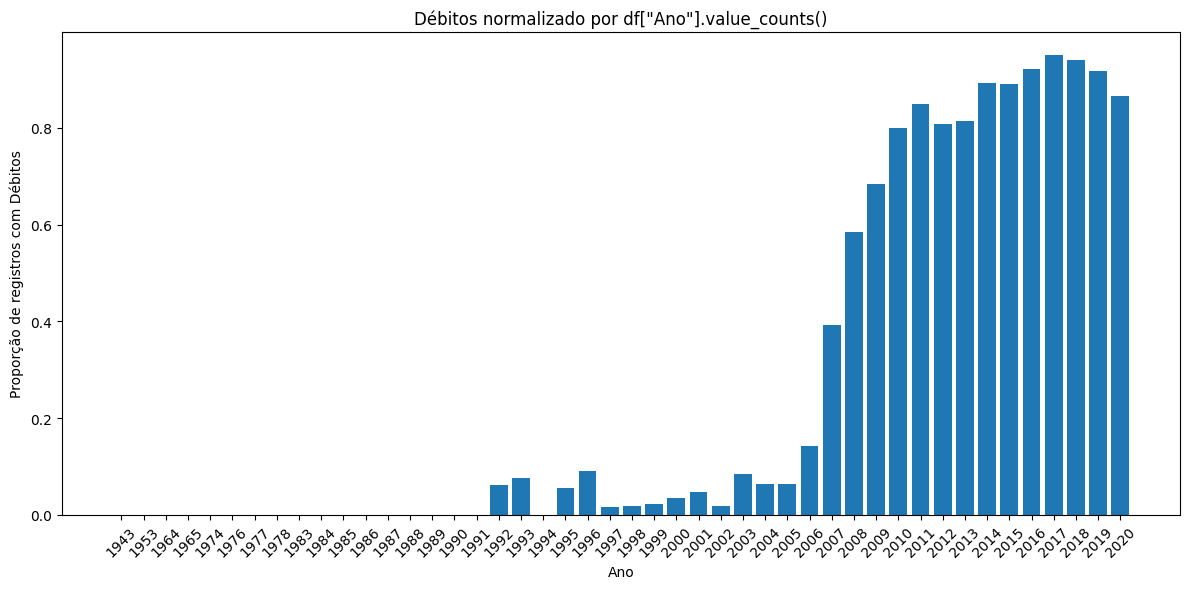

In [33]:
df["Ano"] = pd.to_numeric(df["Ano"], errors="coerce")

# Total de registros por ano
total_por_ano = df["Ano"].value_counts().sort_index()

# Quantidade de registros com Débitos válidos por ano
com_debito_por_ano = df.dropna(subset=["Ano", "Débitos"])["Ano"].value_counts().sort_index()

# Normalização pela contagem total de registros do ano
normalizado = (com_debito_por_ano / total_por_ano).fillna(0).sort_index()

graf = normalizado.reset_index()
graf.columns = ["Ano", "Proporcao_com_Debito"]

plt.figure(figsize=(12, 6))
plt.bar(graf["Ano"].astype(int).astype(str), graf["Proporcao_com_Debito"])
plt.xlabel("Ano")
plt.ylabel("Proporção de registros com Débitos")
plt.title('Débitos normalizado por df["Ano"].value_counts()')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
df = df[df["Preco"].notna()].copy()
df.head()

,ID,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
0,45654403,1399.0,LEXUS,RX 450,2010,SUV,Sim,Hibrido,3.5,186005 km,...,12,13328.0,1,2021-03-14,Sim,FM,8,8497,Usado,Econômico
1,44731507,1018.0,CHEVROLET,Equinox,2011,SUV,Nao,GASOLINA,3,NaN,...,8,16621.0,5,2021-08-08,Sim,AM,4,6796,Usado,Econômico
2,45774419,NaN,HONDA,FIT,2006,Hatchback,Nao,GASOLINA,1.3,200000 km,...,2,8467.0,1,2020-04-14,Sim,FM,5,3382,Usado,Econômico
3,45769185,862.0,FORD,Escape,2011,SUV,Sim,Hibrido,2.5,168966 km,...,0,3607.0,1,2020-01-13,Não,AM/FM,7,1458,Usado,Econômico
4,45809263,446.0,HONDA,FIT,2014,Hatchback,Sim,Gasolina,1.3,91901 km,...,4,11726.0,2,2021-10-11,Não,AM,5,5374,Usado,Econômico


In [35]:
df["Km"].value_counts()

Km
0 km          274
200000 km      67
150000 km      57
100000 km      54
160000 km      54
             ... 
243087 km       1
236698 km       1
43300 km        1
128297 km       1
1700000 km      1
Name: count, Length: 3617, dtype: int64

In [36]:
df["Km"] = pd.to_numeric(
    df["Km"]
      .astype(str)
      .str.strip()
      .str.replace(" km", "", regex=False)
      .str.replace(".", "", regex=False)
      .str.replace(",", ".", regex=False),
    errors="coerce"
)

In [37]:
df["Km"].value_counts()

Km
0.0          274
200000.0      67
150000.0      57
100000.0      54
160000.0      54
            ... 
243087.0       1
236698.0       1
43300.0        1
128297.0       1
1700000.0      1
Name: count, Length: 3617, dtype: int64

In [38]:
df["Volume_motor"].value_counts()

Volume_motor
2            1484
2.5          1050
1.8           785
1.6           628
1.5           568
             ... 
6.8             1
4.0 Turbo       1
2.1 Turbo       1
3.7 Turbo       1
6.4             1
Name: count, Length: 96, dtype: int64

In [39]:
df["Volume_motor"] = pd.to_numeric(
    df["Volume_motor"]
      .astype(str)
      .str.strip()
      .str.replace(",", ".", regex=False),
    errors="coerce"
)

In [40]:
df["Volume_motor"].value_counts()

Volume_motor
2.0    1484
2.5    1050
1.8     785
1.6     628
1.5     568
3.5     524
2.4     428
3.0     360
1.3     242
4.6     164
1.4     146
2.2      99
3.3      99
1.7      76
3.2      67
2.7      64
2.3      56
3.6      53
1.0      52
1.2      52
4.7      46
4.4      42
4.0      41
5.0      32
3.7      31
2.8      26
5.5      25
5.7      23
1.9      19
4.8      19
3.8      18
0.4      11
6.2      11
0.7       9
4.2       9
5.3       6
4.5       6
0.2       5
0.0       5
3.4       4
5.4       4
0.6       4
0.8       4
2.6       4
2.1       4
0.3       2
1.1       2
6.3       2
5.6       2
6.0       2
2.9       2
4.3       2
7.3       1
3.1       1
0.1       1
0.5       1
6.8       1
5.9       1
6.7       1
6.4       1
Name: count, dtype: int64

In [41]:
colunas_excluir = ["Data_ultima_lavagem", "ID", "Faixa_Preco"]

df = df.drop(columns=colunas_excluir, errors="ignore")

In [42]:
df.head()

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Rodas,Cor,Airbags,Preco,Numero_proprietarios,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo
0,1399.0,LEXUS,RX 450,2010,SUV,Sim,Hibrido,3.5,186005.0,6,...,23,Prata,12,13328.0,1,Sim,FM,8,8497,Usado
1,1018.0,CHEVROLET,Equinox,2011,SUV,Nao,GASOLINA,3.0,NaN,6,...,14,Preto,8,16621.0,5,Sim,AM,4,6796,Usado
2,NaN,HONDA,FIT,2006,Hatchback,Nao,GASOLINA,1.3,200000.0,4,...,17,Preto,2,8467.0,1,Sim,FM,5,3382,Usado
3,862.0,FORD,Escape,2011,SUV,Sim,Hibrido,2.5,168966.0,4,...,15,Branco,0,3607.0,1,Não,AM/FM,7,1458,Usado
4,446.0,HONDA,FIT,2014,Hatchback,Sim,Gasolina,1.3,91901.0,4,...,28,Prata,4,11726.0,2,Não,AM,5,5374,Usado
